# Predictive Analytics on Global Suicide Rates (1985–2016)
**SDG 3: Good Health and Well-being**

**CRISP-DM Framework**
- Section 1: Business Understanding
- Section 2: Data Understanding (EDA)
- Section 3: Data Preparation
- Section 4: Model 1 — Random Forest Regression
- Section 5: Model 2 — K-Means Clustering
- Section 6: Model 3 — Facebook Prophet Time Series Forecasting
- Section 7: Evaluation Summary

**Dataset:** WHO Suicide Rates Overview 1985–2016  
**File:** `suicide.csv`

---
## SECTION 1 — Business Understanding

Suicide is a critical global public health issue. According to the WHO, over 700,000 people
die by suicide every year. This project aims to:
1. Identify the socioeconomic drivers of suicide rates (Regression)
2. Segment countries into risk profiles to guide targeted intervention (Clustering)
3. Forecast future global suicide trends to inform policy (Time Series)

This directly supports **UN SDG 3: Good Health and Well-being**, specifically target 3.4:
By 2030, reduce by one third premature mortality from non-communicable diseases
through prevention and promote mental health and well-being.

---
## SECTION 2 — Data Understanding & EDA

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Install required libraries
# Run this cell first if prophet or scikit-learn is not installed.
# Uncomment the line below if running for the first time:
# ─────────────────────────────────────────────────────────────
# !pip install prophet scikit-learn pandas matplotlib seaborn numpy --quiet

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Import all libraries
# We import everything upfront so the notebook runs top-to-bottom
# without missing dependency errors mid-run.
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, silhouette_score
)
from prophet import Prophet

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Load the dataset
# The file is named suicide.csv and must be in the same folder
# as this notebook. Update path if stored elsewhere.
# ─────────────────────────────────────────────────────────────

df = pd.read_csv('suicide.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 27820 rows x 12 columns


,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Column info & missing value audit
# Before cleaning, we inspect every column:
#   - dtype tells us if a numeric column was loaded as string
#   - null counts tell us where imputation is needed
# ─────────────────────────────────────────────────────────────

print('=' * 55)
print('COLUMN INFO')
print('=' * 55)
df.info()

print('\n' + '=' * 55)
print('MISSING VALUES PER COLUMN')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

COLUMN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB

MISSING VALUES PER COLUMN
              Missing Count  Missing %
HDI for year          19456      69.94


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Descriptive statistics
# .describe() shows distribution of numeric columns:
# min, max, mean, std, quartiles — useful for spotting outliers.
# ─────────────────────────────────────────────────────────────

df.describe(include='all')

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
count,27820,27820.000000,27820,27820,27820.000000,2.782000e+04,27820.000000,27820,8364.000000,27820,27820.000000,27820
unique,101,NaN,2,6,NaN,NaN,NaN,2321,NaN,2321,NaN,6
top,Austria,NaN,male,15-24 years,NaN,NaN,NaN,Uzbekistan2014,NaN,"63,067,077,179",NaN,Generation X
freq,382,NaN,13910,4642,NaN,NaN,NaN,12,NaN,12,NaN,6408
mean,NaN,2001.258375,NaN,NaN,242.574407,1.844794e+06,12.816097,NaN,0.776601,NaN,16866.464414,NaN
std,NaN,8.469055,NaN,NaN,902.047917,3.911779e+06,18.961511,NaN,0.093367,NaN,18887.576472,NaN
min,NaN,1985.000000,NaN,NaN,0.000000,2.780000e+02,0.000000,NaN,0.483000,NaN,251.000000,NaN
25%,NaN,1995.000000,NaN,NaN,3.000000,9.749850e+04,0.920000,NaN,0.713000,NaN,3447.000000,NaN
50%,NaN,2002.000000,NaN,NaN,25.000000,4.301500e+05,5.990000,NaN,0.779000,NaN,9372.000000,NaN
75%,NaN,2008.000000,NaN,NaN,131.000000,1.486143e+06,16.620000,NaN,0.855000,NaN,24874.000000,NaN


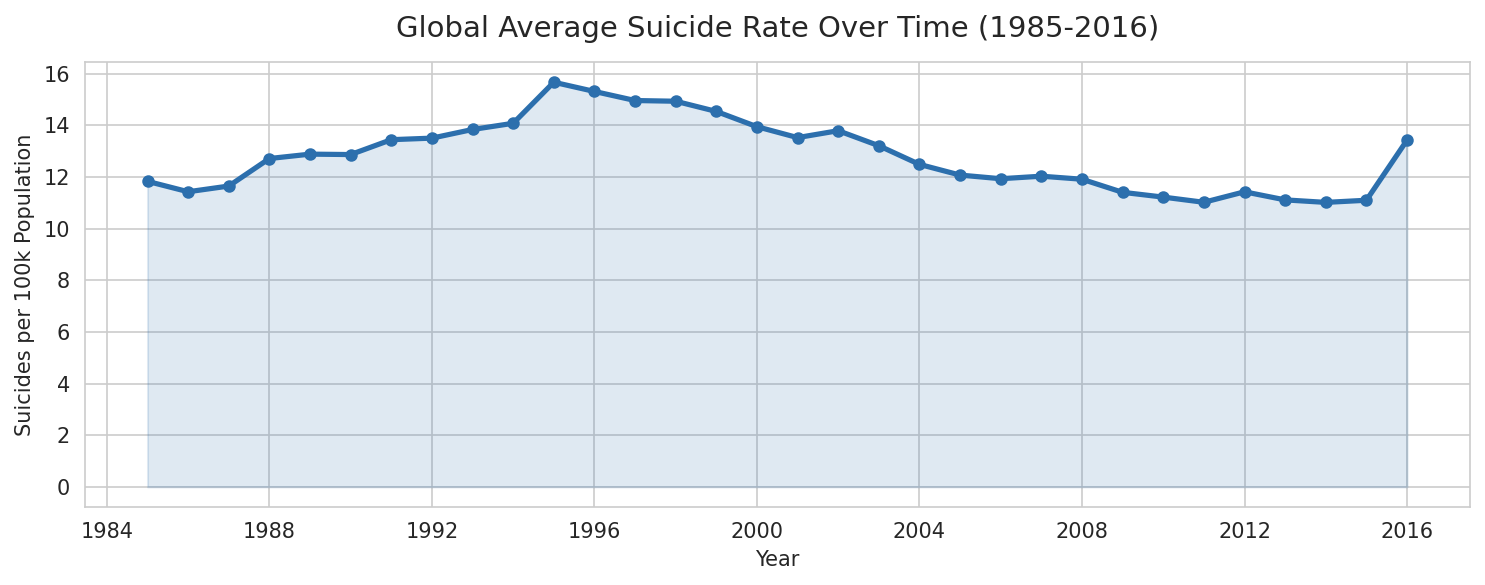

Saved: plot_01_global_trend.png


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — EDA PLOT 1: Global suicide trend over time
# Group by year and compute the mean suicides/100k pop globally.
# This gives the macro trend that Prophet will later forecast.
# ─────────────────────────────────────────────────────────────

yearly_avg = df.groupby('year')['suicides/100k pop'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly_avg['year'], yearly_avg['suicides/100k pop'],
        color='#2c6fad', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(yearly_avg['year'], yearly_avg['suicides/100k pop'],
                alpha=0.15, color='#2c6fad')
ax.set_title('Global Average Suicide Rate Over Time (1985-2016)', fontsize=14, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Suicides per 100k Population')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('plot_01_global_trend.png', bbox_inches='tight')
plt.show()
print('Saved: plot_01_global_trend.png')

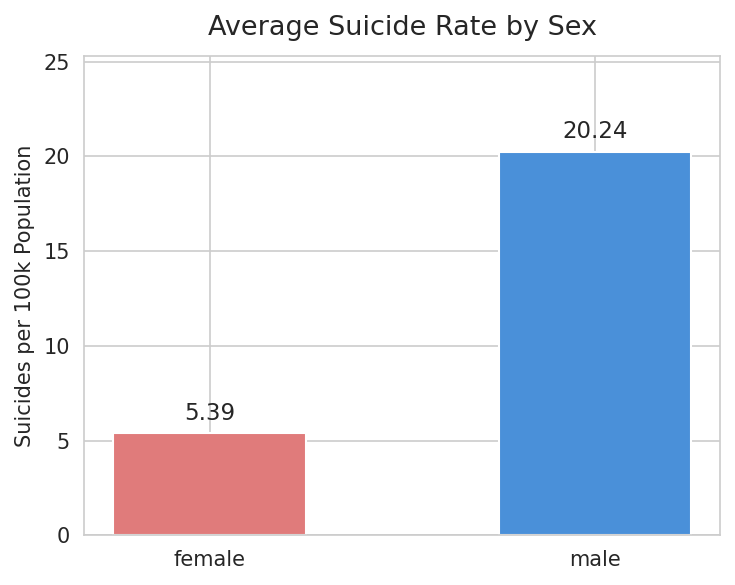

Saved: plot_02_by_sex.png


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — EDA PLOT 2: Suicide rate by sex
# Reveals the well-documented gender disparity in suicide rates.
# ─────────────────────────────────────────────────────────────

sex_avg = df.groupby('sex')['suicides/100k pop'].mean().reset_index()

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#e07b7b', '#4a90d9']
bars = ax.bar(sex_avg['sex'], sex_avg['suicides/100k pop'],
               color=colors, width=0.5, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=11)
ax.set_title('Average Suicide Rate by Sex', fontsize=13, pad=10)
ax.set_ylabel('Suicides per 100k Population')
ax.set_ylim(0, sex_avg['suicides/100k pop'].max() * 1.25)
plt.tight_layout()
plt.savefig('plot_02_by_sex.png', bbox_inches='tight')
plt.show()
print('Saved: plot_02_by_sex.png')

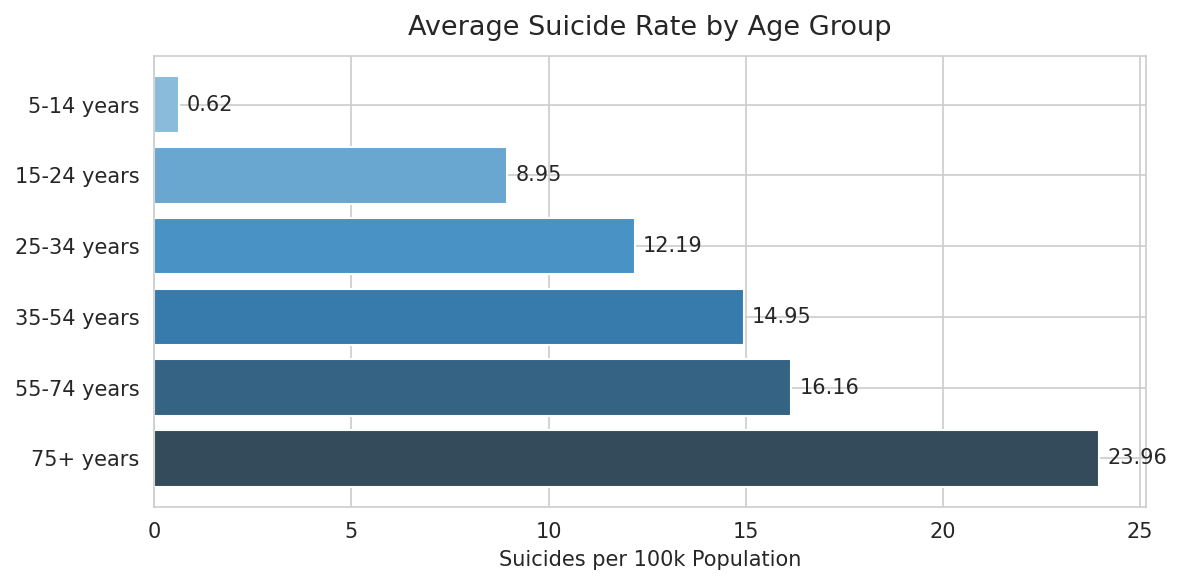

Saved: plot_03_by_age.png


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — EDA PLOT 3: Suicide rate by age group
# Age is a critical risk factor. Shows which groups are most
# vulnerable — informs targeted policy interventions.
# ─────────────────────────────────────────────────────────────

age_order = ['5-14 years', '15-24 years', '25-34 years',
             '35-54 years', '55-74 years', '75+ years']

age_avg = (df.groupby('age')['suicides/100k pop']
             .mean()
             .reindex(age_order)
             .reset_index())

fig, ax = plt.subplots(figsize=(8, 4))
palette = sns.color_palette('Blues_d', len(age_order))
bars = ax.barh(age_avg['age'], age_avg['suicides/100k pop'],
               color=palette, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
ax.set_title('Average Suicide Rate by Age Group', fontsize=13, pad=10)
ax.set_xlabel('Suicides per 100k Population')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plot_03_by_age.png', bbox_inches='tight')
plt.show()
print('Saved: plot_03_by_age.png')

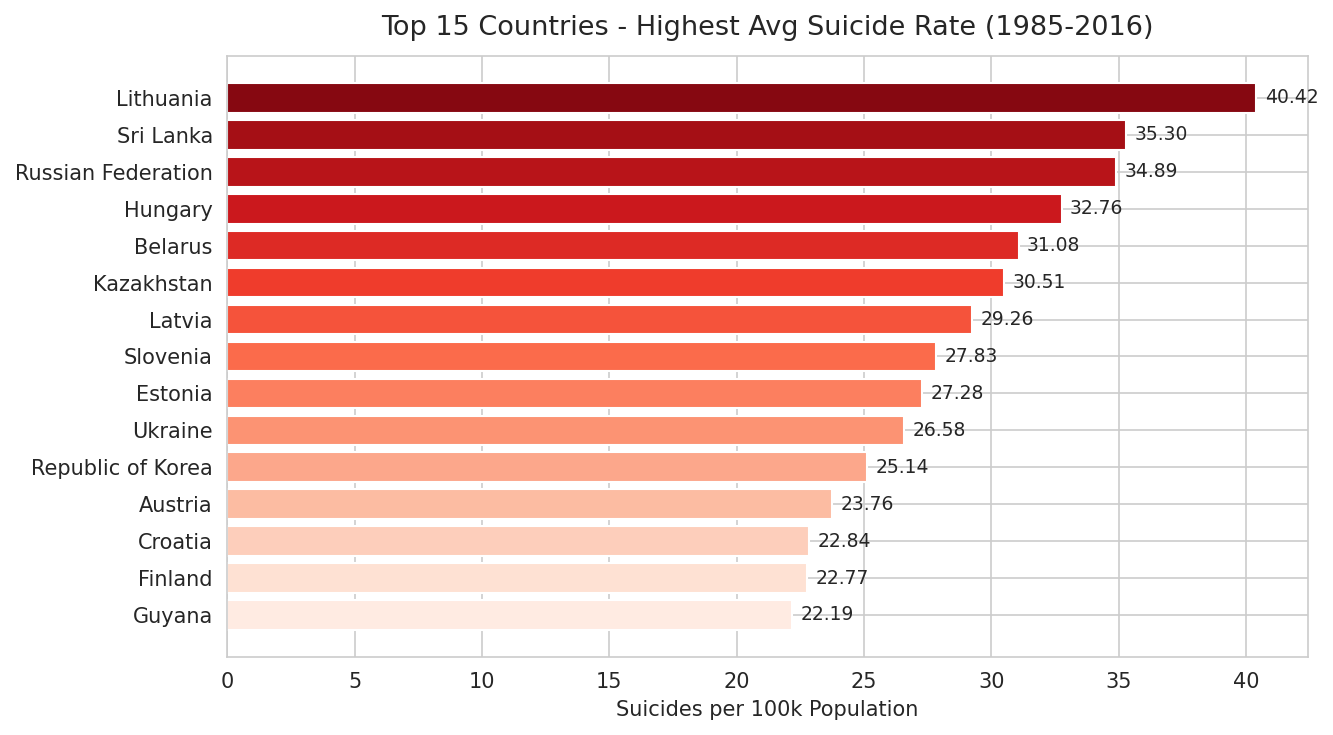

Saved: plot_04_top_countries.png


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — EDA PLOT 4: Top 15 countries by average suicide rate
# Reveals which nations carry the highest burden, which will
# directly correspond to cluster assignments in Model 2.
# ─────────────────────────────────────────────────────────────

country_avg = (df.groupby('country')['suicides/100k pop']
                 .mean()
                 .sort_values(ascending=False)
                 .head(15)
                 .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette('Reds_r', 15)
bars = ax.barh(country_avg['country'][::-1],
               country_avg['suicides/100k pop'][::-1],
               color=palette[::-1], edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.set_title('Top 15 Countries - Highest Avg Suicide Rate (1985-2016)', fontsize=13, pad=10)
ax.set_xlabel('Suicides per 100k Population')
plt.tight_layout()
plt.savefig('plot_04_top_countries.png', bbox_inches='tight')
plt.show()
print('Saved: plot_04_top_countries.png')

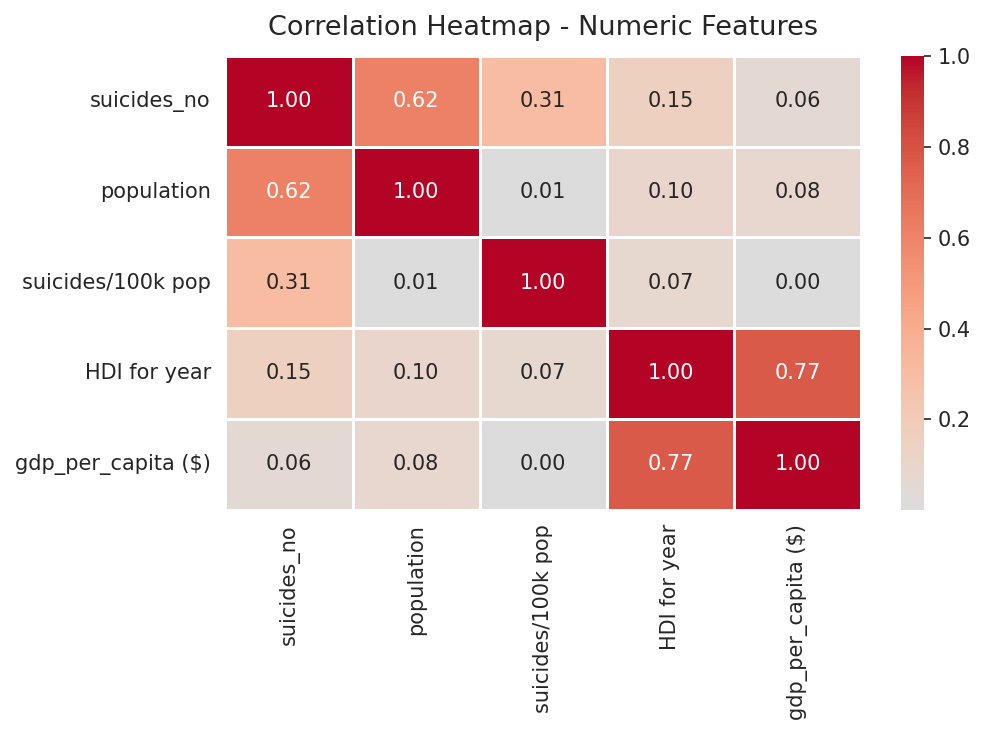

Saved: plot_05_correlation.png


In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — EDA PLOT 5: Correlation heatmap
# Shows relationships between numeric variables before modeling.
# We check which column names exist first to avoid KeyErrors.
# ─────────────────────────────────────────────────────────────

num_candidates = ['suicides_no', 'population', 'suicides/100k pop',
                  'HDI for year', 'gdp_per_capita ($)']
num_cols = [c for c in num_candidates if c in df.columns]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Heatmap - Numeric Features', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('plot_05_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: plot_05_correlation.png')

---
## SECTION 3 — Data Preparation

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 11 — Make a clean working copy
# Never modify the original df directly so we can always
# refer back to raw data for comparison.
# ─────────────────────────────────────────────────────────────

df_clean = df.copy()
print(f'Working copy created: {df_clean.shape}')

Working copy created: (27820, 12)


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 12 — Rename columns for ease of use
# 'suicides/100k pop' has special characters that cause issues
# in some pandas operations. We rename it and other long names.
# ─────────────────────────────────────────────────────────────

rename_map = {
    'suicides/100k pop': 'suicide_rate',
    'HDI for year': 'HDI',
    'gdp_for_year ($)': 'gdp_for_year',
    ' gdp_for_year ($) ': 'gdp_for_year',
    'gdp_per_capita ($)': 'gdp_per_capita',
    'country-year': 'country_year'
}

# Only rename columns that actually exist
rename_map = {k: v for k, v in rename_map.items() if k in df_clean.columns}
df_clean.rename(columns=rename_map, inplace=True)

print('Columns after rename:')
print(df_clean.columns.tolist())

Columns after rename:
['country', 'year', 'sex', 'age', 'suicides_no', 'population', 'suicide_rate', 'country_year', 'HDI', 'gdp_for_year', 'gdp_per_capita', 'generation']


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 13 — Drop redundant columns
# 'country_year' is a composite string of country + year.
# It is redundant and could cause data leakage.
# ─────────────────────────────────────────────────────────────

cols_to_drop = [c for c in ['country_year'] if c in df_clean.columns]
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Dropped: {cols_to_drop}')
print(f'Remaining: {df_clean.columns.tolist()}')

Dropped: ['country_year']
Remaining: ['country', 'year', 'sex', 'age', 'suicides_no', 'population', 'suicide_rate', 'HDI', 'gdp_for_year', 'gdp_per_capita', 'generation']


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 14 — Fix GDP for year column (string -> float)
# The GDP column may be stored as a string with commas
# e.g. '2,156,624,900'. Strip commas and cast to float.
# ─────────────────────────────────────────────────────────────

if 'gdp_for_year' in df_clean.columns:
    df_clean['gdp_for_year'] = (
        df_clean['gdp_for_year']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace('nan', np.nan)
        .astype(float)
    )
    print(f'gdp_for_year dtype: {df_clean["gdp_for_year"].dtype}')
    print(f'Sample: {df_clean["gdp_for_year"].head(3).values}')
else:
    print('gdp_for_year not found - check column names.')

gdp_for_year dtype: float64
Sample: [2.1566249e+09 2.1566249e+09 2.1566249e+09]


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 15 — Impute missing HDI values using KNN Imputer
# HDI has ~30% missing values. Dropping rows would lose too
# much data. KNN Imputer fills missing values using the 5
# nearest neighbors in feature space - more accurate than
# simple mean/median imputation for structured data.
# ─────────────────────────────────────────────────────────────

if 'HDI' in df_clean.columns:
    print(f'HDI missing before imputation: {df_clean["HDI"].isnull().sum()}')
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    imputer = KNNImputer(n_neighbors=5)
    df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])
    print(f'HDI missing after imputation:  {df_clean["HDI"].isnull().sum()}')
    print('KNN Imputation complete.')
else:
    print('HDI column not found - skipping imputation.')

HDI missing before imputation: 19456
HDI missing after imputation:  0
KNN Imputation complete.


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 16 — Encode categorical columns
# ML models require numeric inputs. We use LabelEncoder on:
# sex, age, generation, country.
# We store each encoder in a dict for later inverse-transform.
# ─────────────────────────────────────────────────────────────

cat_cols = ['sex', 'age', 'generation', 'country']
cat_cols = [c for c in cat_cols if c in df_clean.columns]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le
    print(f'Encoded "{col}" -> "{col}_encoded" | Classes: {list(le.classes_)}')

print('\nEncoding complete.')

Encoded "sex" -> "sex_encoded" | Classes: ['female', 'male']
Encoded "age" -> "age_encoded" | Classes: ['15-24 years', '25-34 years', '35-54 years', '5-14 years', '55-74 years', '75+ years']
Encoded "generation" -> "generation_encoded" | Classes: ['Boomers', 'G.I. Generation', 'Generation X', 'Generation Z', 'Millenials', 'Silent']
Encoded "country" -> "country_encoded" | Classes: ['Albania', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cabo Verde', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominica', 'Ecuador', 'El Salvador', 'Estonia', 'Fiji', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Grenada', 'Guatemala', 'Guyana', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Kazakhstan', 'Kiribati', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Li

In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 17 — Final check on cleaned dataframe
# ─────────────────────────────────────────────────────────────

print(f'Final cleaned shape: {df_clean.shape}')
remaining_nulls = df_clean.isnull().sum()
print(f'Remaining nulls:\n{remaining_nulls[remaining_nulls > 0]}')
df_clean.head(3)

Final cleaned shape: (27820, 15)
Remaining nulls:
Series([], dtype: int64)


,country,year,sex,age,suicides_no,population,suicide_rate,HDI,gdp_for_year,gdp_per_capita,generation,sex_encoded,age_encoded,generation_encoded,country_encoded
0,Albania,1987.0,male,15-24 years,21.0,312900.0,6.71,0.65,2.156625e+09,796.0,Generation X,1,0,2,0
1,Albania,1987.0,male,35-54 years,16.0,308000.0,5.19,0.65,2.156625e+09,796.0,Silent,1,2,5,0
2,Albania,1987.0,female,15-24 years,14.0,289700.0,4.83,0.65,2.156625e+09,796.0,Generation X,0,0,2,0


---
## SECTION 4 — Model 1: Random Forest Regression
**Goal:** Predict `suicide_rate` from socioeconomic and demographic features.  
**Why Random Forest?** Handles non-linear relationships, robust to outliers, and provides
feature importance scores critical for policy interpretation.

In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 18 — Define features (X) and target (y) for regression
# We EXCLUDE suicides_no because it is a direct component of
# the target (suicide_rate = suicides_no / population * 100k)
# -- including it would cause data leakage.
# ─────────────────────────────────────────────────────────────

reg_feature_candidates = [
    'sex_encoded', 'age_encoded', 'generation_encoded',
    'HDI', 'gdp_per_capita', 'gdp_for_year', 'population', 'year'
]
reg_features = [f for f in reg_feature_candidates if f in df_clean.columns]

X_reg = df_clean[reg_features].copy()
y_reg = df_clean['suicide_rate'].copy()

mask = y_reg.notna()
X_reg, y_reg = X_reg[mask], y_reg[mask]

print(f'Features: {reg_features}')
print(f'X shape: {X_reg.shape} | y shape: {y_reg.shape}')

Features: ['sex_encoded', 'age_encoded', 'generation_encoded', 'HDI', 'gdp_per_capita', 'gdp_for_year', 'population', 'year']
X shape: (27820, 8) | y shape: (27820,)


In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 19 — Train/Test split (80/20)
# random_state=42 ensures reproducibility across all runs.
# ─────────────────────────────────────────────────────────────

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)
print(f'Training set: {X_train_r.shape[0]} samples')
print(f'Test set:     {X_test_r.shape[0]} samples')

Training set: 22256 samples
Test set:     5564 samples


In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 20 — Hyperparameter tuning with GridSearchCV
# Tunes 3 key Random Forest hyperparameters:
#   n_estimators     : number of trees
#   max_depth        : controls overfitting
#   min_samples_split: min samples to split a node
# cv=5 = 5-fold cross-validation on training set.
# This may take 1-3 minutes depending on hardware.
# ─────────────────────────────────────────────────────────────

print('Running GridSearchCV for Random Forest... (please wait)')

param_grid_rf = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [None, 10, 20],
    'min_samples_split':[2, 5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train_r, y_train_r)

print(f'\nBest parameters: {grid_search_rf.best_params_}')
print(f'Best CV RMSE:    {-grid_search_rf.best_score_:.4f}')

Running GridSearchCV for Random Forest... (please wait)
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE:    9.9338


In [21]:
# ─────────────────────────────────────────────────────────────
# CELL 21 — Evaluate best Random Forest on test set
# We use the best estimator found by GridSearchCV to predict
# on the held-out test set (data the model has never seen).
# ─────────────────────────────────────────────────────────────

best_rf   = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_r)

rmse_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_rf))
mae_rf  = mean_absolute_error(y_test_r, y_pred_rf)
r2_rf   = r2_score(y_test_r, y_pred_rf)

print('=' * 45)
print('RANDOM FOREST REGRESSION - TEST METRICS')
print('=' * 45)
print(f'  RMSE : {rmse_rf:.4f}  (lower is better)')
print(f'  MAE  : {mae_rf:.4f}  (lower is better)')
print(f'  R2   : {r2_rf:.4f}  (closer to 1 is better)')
print('=' * 45)

RANDOM FOREST REGRESSION - TEST METRICS
  RMSE : 9.4006  (lower is better)
  MAE  : 4.5694  (lower is better)
  R2   : 0.7471  (closer to 1 is better)


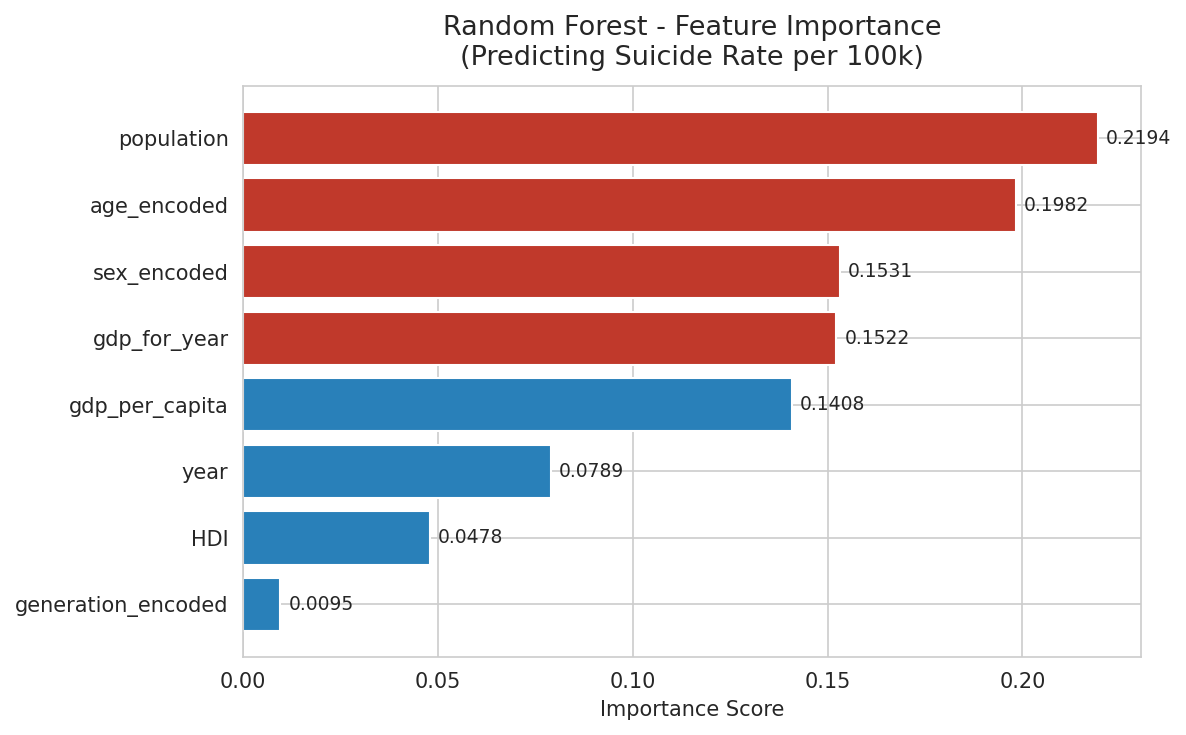

Saved: plot_06_feature_importance.png


In [22]:
# ─────────────────────────────────────────────────────────────
# CELL 22 — PLOT: Feature Importance
# Shows which variables the forest relied on most.
# Key business insight: tells policymakers WHERE to intervene.
# ─────────────────────────────────────────────────────────────

importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': reg_features, 'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_imp = ['#c0392b' if v > feat_imp_df['Importance'].median() else '#2980b9'
              for v in feat_imp_df['Importance']]
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors_imp, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
ax.set_title('Random Forest - Feature Importance\n(Predicting Suicide Rate per 100k)',
             fontsize=13, pad=10)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_06_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: plot_06_feature_importance.png')

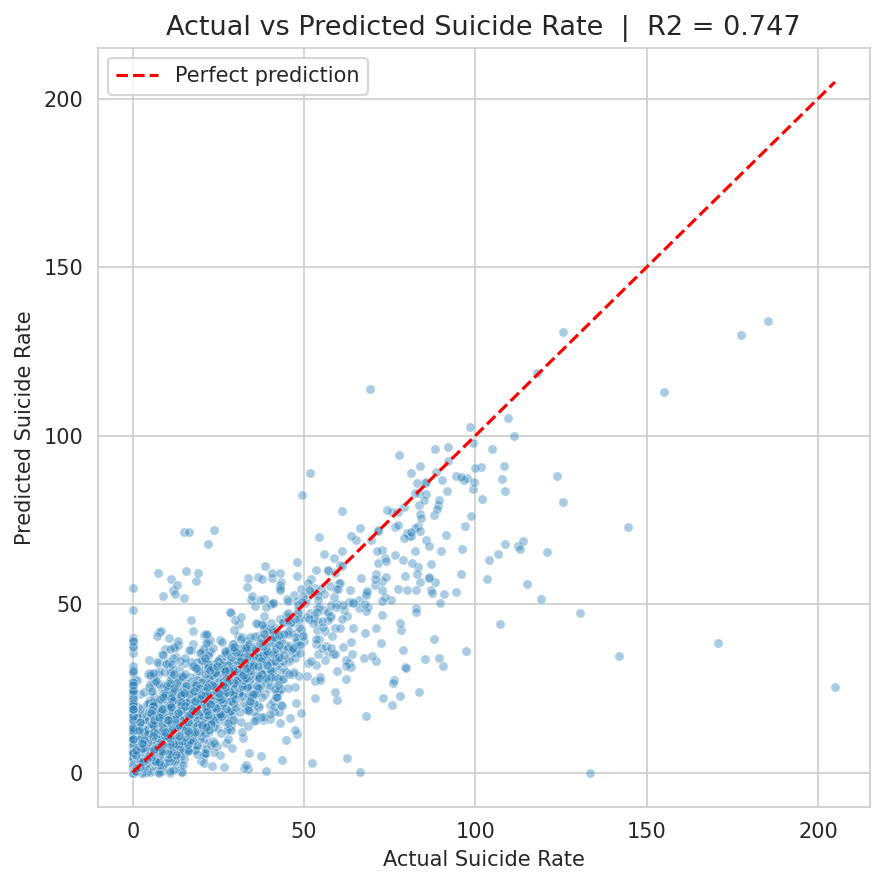

Saved: plot_07_actual_vs_predicted.png


In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 23 — PLOT: Actual vs Predicted scatter
# Perfect model = all points on the red diagonal.
# Spread around the line shows prediction error visually.
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_r, y_pred_rf, alpha=0.4, color='#2980b9',
           edgecolors='white', linewidth=0.5, s=20)
max_val = max(y_test_r.max(), y_pred_rf.max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Suicide Rate')
ax.set_ylabel('Predicted Suicide Rate')
ax.set_title(f'Actual vs Predicted Suicide Rate  |  R2 = {r2_rf:.3f}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('plot_07_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print('Saved: plot_07_actual_vs_predicted.png')

---
## SECTION 5 — Model 2: K-Means Clustering
**Goal:** Segment countries into distinct risk groups based on average suicide rate, GDP, and HDI.  
**Why K-Means?** Interpretable, scalable, and produces clearly defined cluster centroids
that map directly to policy categories (Low Risk, Moderate Risk, High Risk, etc.).

In [24]:
# ─────────────────────────────────────────────────────────────
# CELL 24 — Aggregate to one row per country for clustering
# We compute the mean of all metrics per country across all
# years and demographic groups. Each point = one country profile.
# ─────────────────────────────────────────────────────────────

cluster_agg_candidates = ['suicide_rate', 'HDI', 'gdp_per_capita', 'gdp_for_year', 'population']
cluster_agg_cols = [c for c in cluster_agg_candidates if c in df_clean.columns]

country_profile = (
    df_clean.groupby('country')[cluster_agg_cols]
    .mean()
    .reset_index()
)

print(f'Country profiles: {country_profile.shape}')
print(f'Clustering features: {cluster_agg_cols}')
country_profile.head()

Country profiles: (101, 6)
Clustering features: ['suicide_rate', 'HDI', 'gdp_per_capita', 'gdp_for_year', 'population']


,country,suicide_rate,HDI,gdp_per_capita,gdp_for_year,population
0,Albania,3.502879,0.693591,1859.045455,5.211661e+09,2.360813e+05
1,Antigua and Barbuda,0.552901,0.692778,10448.185185,8.035452e+08,6.142679e+03
2,Argentina,10.469328,0.798452,7914.096774,2.742565e+11,2.784907e+06
3,Armenia,3.275872,0.695591,1873.919463,5.386592e+09,2.595576e+05
4,Aruba,9.503095,0.659786,24221.642857,2.196223e+09,7.498077e+03


In [25]:
# ─────────────────────────────────────────────────────────────
# CELL 25 — Scale features before K-Means
# K-Means uses Euclidean distance. Without scaling, GDP (billions)
# would dominate HDI (0-1 range) completely.
# StandardScaler brings all features to mean=0, std=1.
# ─────────────────────────────────────────────────────────────

X_cluster = country_profile[cluster_agg_cols].dropna()
valid_countries = country_profile.loc[X_cluster.index, 'country']

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print(f'Clustering on {X_cluster_scaled.shape[0]} countries.')
print('Features scaled to mean=0, std=1.')

Clustering on 101 countries.
Features scaled to mean=0, std=1.


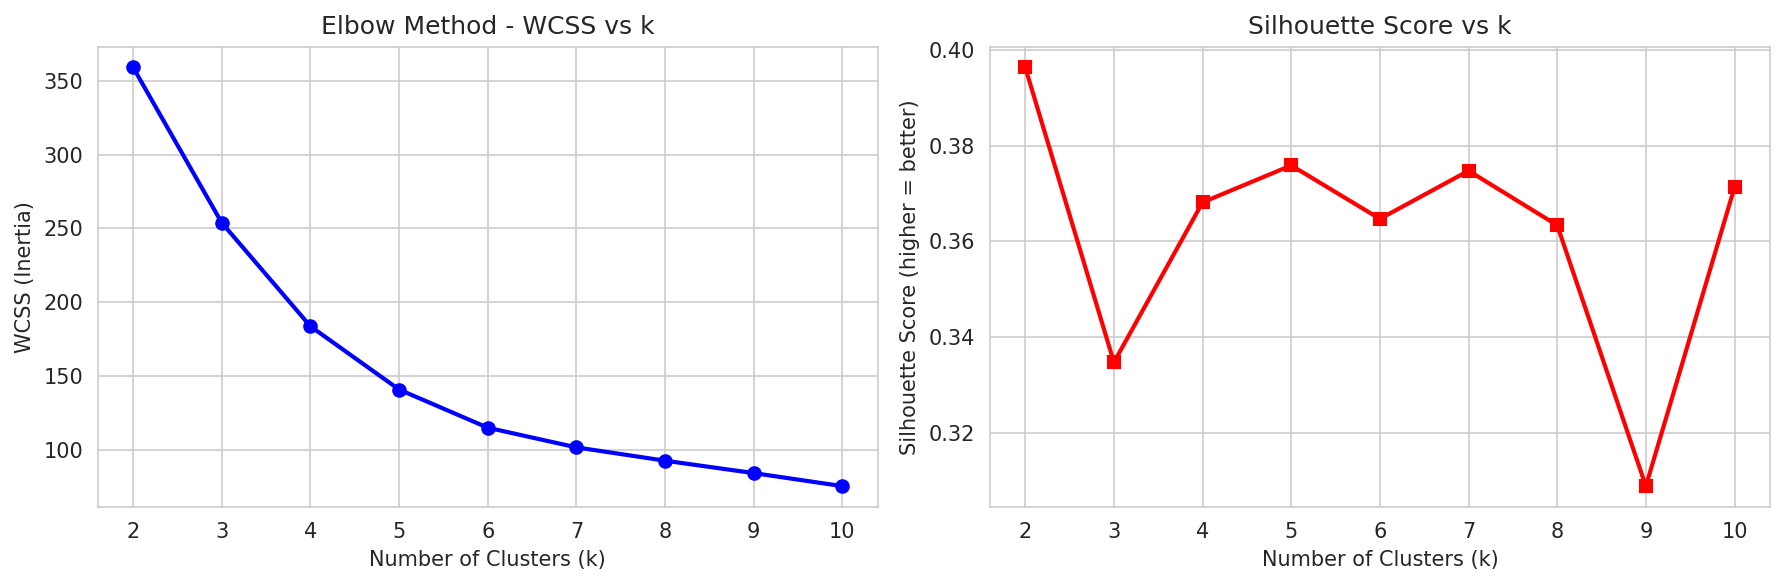

Saved: plot_08_elbow_silhouette.png

Best k by Silhouette Score: 2 (score = 0.3964)


In [26]:
# ─────────────────────────────────────────────────────────────
# CELL 26 — Elbow Method + Silhouette Score to find optimal k
# Run K-Means for k = 2 to 10.
# Elbow: where WCSS drop flattens = best k.
# Silhouette: higher score = better cluster separation.
# ─────────────────────────────────────────────────────────────

wcss, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), wcss, 'bo-', linewidth=2, markersize=6)
axes[0].set_title('Elbow Method - WCSS vs k', fontsize=12)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS (Inertia)')

axes[1].plot(list(k_range), sil_scores, 'rs-', linewidth=2, markersize=6)
axes[1].set_title('Silhouette Score vs k', fontsize=12)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')

plt.tight_layout()
plt.savefig('plot_08_elbow_silhouette.png', bbox_inches='tight')
plt.show()
print('Saved: plot_08_elbow_silhouette.png')

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'\nBest k by Silhouette Score: {best_k} (score = {max(sil_scores):.4f})')

In [27]:
# ─────────────────────────────────────────────────────────────
# CELL 27 — Fit final K-Means with optimal k
# Uses the k selected by Silhouette Score.
# Change OPTIMAL_K manually if you prefer a different k.
# ─────────────────────────────────────────────────────────────

OPTIMAL_K = best_k  # change manually if desired, e.g. OPTIMAL_K = 3

final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster_scaled)

country_profile_clustered = country_profile.loc[X_cluster.index].copy()
country_profile_clustered['cluster'] = cluster_labels

print(f'K-Means fitted with k={OPTIMAL_K}')
print(f'Silhouette Score: {silhouette_score(X_cluster_scaled, cluster_labels):.4f}')
print('\nCountries per cluster:')
print(country_profile_clustered['cluster'].value_counts().sort_index())

K-Means fitted with k=2
Silhouette Score: 0.3964

Countries per cluster:
cluster
0    76
1    25
Name: count, dtype: int64


In [28]:
# ─────────────────────────────────────────────────────────────
# CELL 28 — Assign human-readable risk labels to clusters
# Sort clusters by average suicide_rate (lowest to highest)
# and assign descriptive labels: Low Risk, Moderate Risk, etc.
# ─────────────────────────────────────────────────────────────

cluster_summary = (
    country_profile_clustered
    .groupby('cluster')[cluster_agg_cols]
    .mean()
    .sort_values('suicide_rate')
)

risk_labels = ['Low Risk', 'Moderate Risk', 'High Risk',
               'Very High Risk', 'Critical Risk', 'Extreme Risk']
label_map = {cluster_id: risk_labels[i]
             for i, cluster_id in enumerate(cluster_summary.index)}

country_profile_clustered['risk_label'] = (
    country_profile_clustered['cluster'].map(label_map)
)

print('Cluster Summary (mean values):')
print(cluster_summary.round(2))
print('\nRisk Label Mapping:', label_map)

Cluster Summary (mean values):
         suicide_rate   HDI  gdp_per_capita  gdp_for_year  population
cluster                                                              
0               11.03  0.73         9163.14  6.364896e+10   841710.94
1               15.04  0.83        36493.99  1.236971e+12  3745575.02

Risk Label Mapping: {0: 'Low Risk', 1: 'Moderate Risk'}


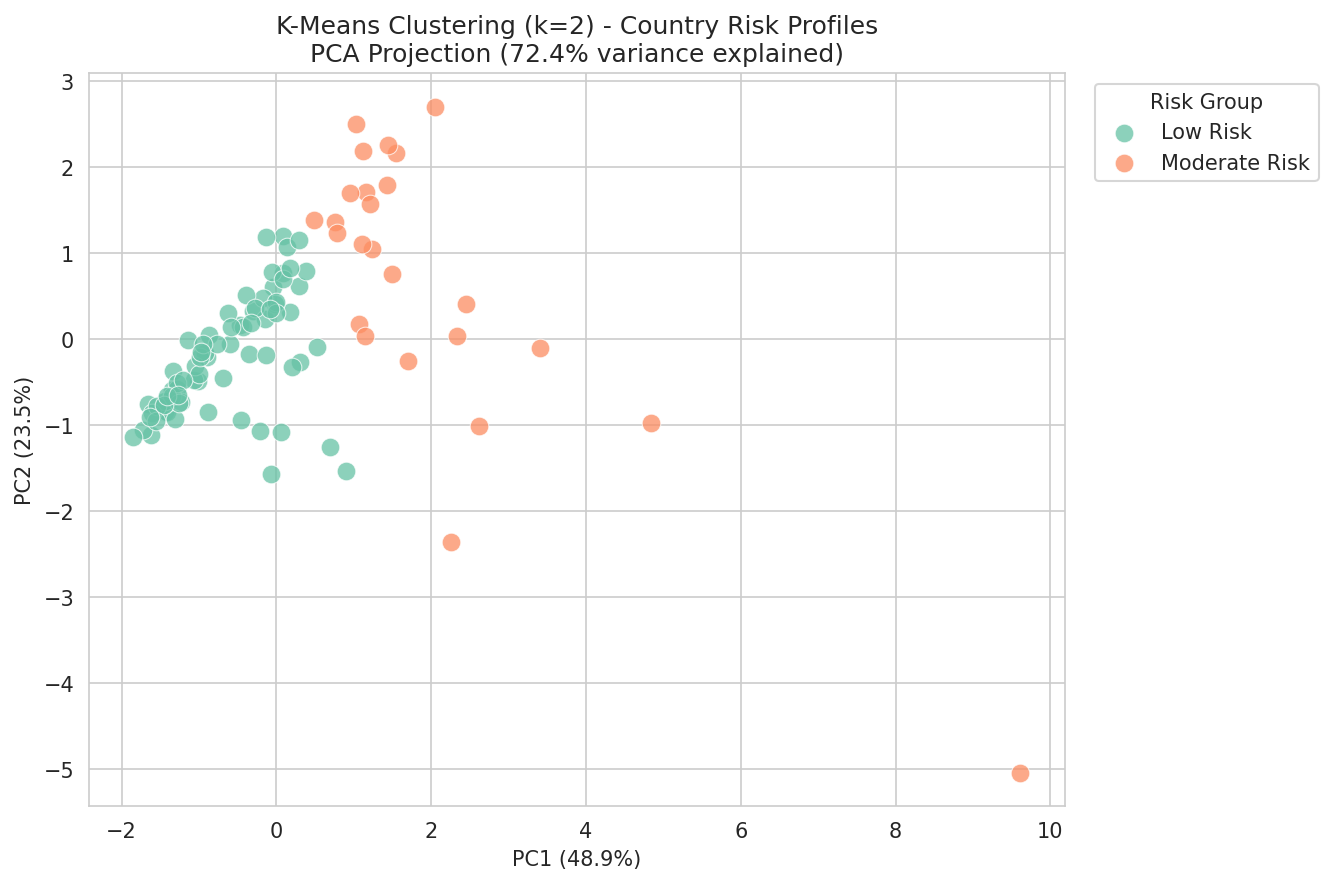

Saved: plot_09_clusters_pca.png


In [29]:
# ─────────────────────────────────────────────────────────────
# CELL 29 — PLOT: PCA 2D Cluster Visualization
# Reduces multi-dimensional cluster space to 2 PCA components
# for a 2D scatter plot. Standard cluster visualization.
# ─────────────────────────────────────────────────────────────

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1],
    'risk_label': country_profile_clustered['risk_label'].values,
    'country': valid_countries.values
})

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('Set2', OPTIMAL_K)

for i, (label, group) in enumerate(pca_df.groupby('risk_label')):
    ax.scatter(group['PC1'], group['PC2'], label=label, s=80,
               alpha=0.75, color=palette[i], edgecolors='white', linewidth=0.5)

var_explained = pca.explained_variance_ratio_.sum() * 100
ax.set_title(
    f'K-Means Clustering (k={OPTIMAL_K}) - Country Risk Profiles\n'
    f'PCA Projection ({var_explained:.1f}% variance explained)',
    fontsize=12
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(title='Risk Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_09_clusters_pca.png', bbox_inches='tight')
plt.show()
print('Saved: plot_09_clusters_pca.png')

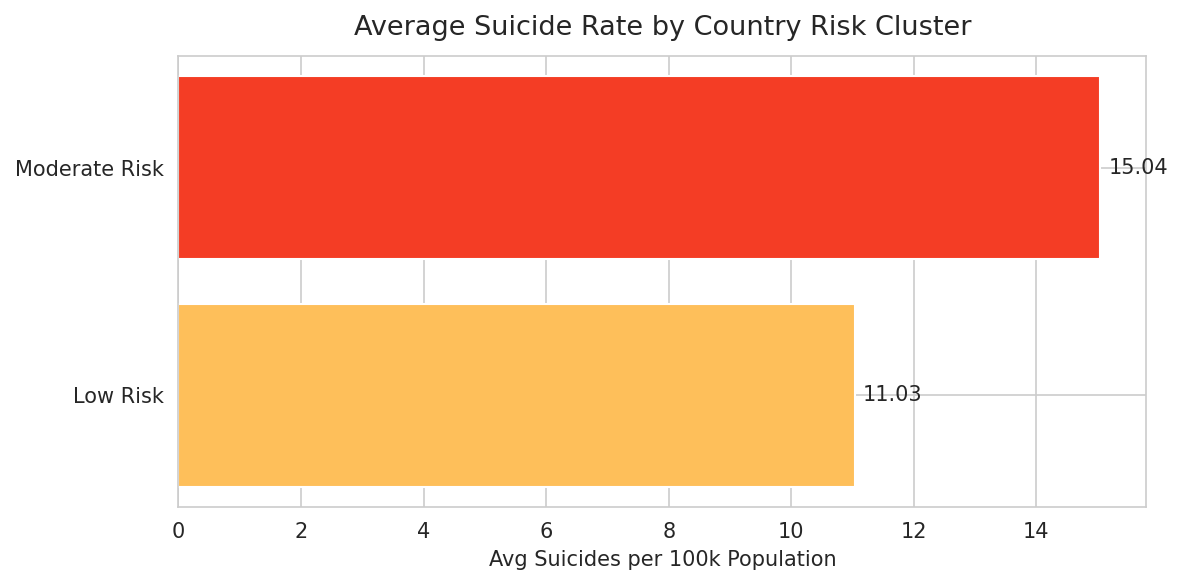

Saved: plot_10_cluster_bar.png


In [30]:
# ─────────────────────────────────────────────────────────────
# CELL 30 — PLOT: Cluster bar chart - avg suicide rate per group
# Most white-paper-friendly output from Model 2.
# ─────────────────────────────────────────────────────────────

cluster_bar = (
    country_profile_clustered
    .groupby('risk_label')['suicide_rate']
    .mean().sort_values().reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
colors_cluster = sns.color_palette('YlOrRd', len(cluster_bar))
bars = ax.barh(cluster_bar['risk_label'], cluster_bar['suicide_rate'],
               color=colors_cluster, edgecolor='white')
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=10)
ax.set_title('Average Suicide Rate by Country Risk Cluster', fontsize=13, pad=10)
ax.set_xlabel('Avg Suicides per 100k Population')
plt.tight_layout()
plt.savefig('plot_10_cluster_bar.png', bbox_inches='tight')
plt.show()
print('Saved: plot_10_cluster_bar.png')

In [31]:
# ─────────────────────────────────────────────────────────────
# CELL 31 — Print sample countries per cluster
# Useful for the white paper to name specific countries
# per risk tier in the narrative.
# ─────────────────────────────────────────────────────────────

print('Sample Countries per Risk Cluster:\n')
for label in sorted(country_profile_clustered['risk_label'].unique()):
    countries_in_cluster = (
        country_profile_clustered[country_profile_clustered['risk_label'] == label]
        .sort_values('suicide_rate', ascending=False)['country'].tolist()
    )
    preview = ', '.join(countries_in_cluster[:8])
    suffix = '...' if len(countries_in_cluster) > 8 else ''
    print(f'  {label}: {preview}{suffix}')

Sample Countries per Risk Cluster:

  Low Risk: Lithuania, Sri Lanka, Hungary, Belarus, Kazakhstan, Latvia, Slovenia, Estonia...
  Moderate Risk: Russian Federation, Republic of Korea, Austria, Finland, France, Japan, Belgium, Switzerland...


---
## SECTION 6 — Model 3: Facebook Prophet Time Series Forecasting
**Goal:** Forecast global average suicide rates from 2017 to 2030 using historical yearly data (1985-2016).  
**Why Prophet?** Designed for yearly/monthly/daily data with trend changepoints. Interpretable,
robust to missing data, and produces confidence intervals ideal for policy communication.

In [32]:
# ─────────────────────────────────────────────────────────────
# CELL 32 — Prepare the time series dataframe for Prophet
# Prophet requires exactly two columns:
#   'ds' -- the date/timestamp column
#   'y'  -- the value to forecast
# We aggregate to global yearly average suicide rate.
# ─────────────────────────────────────────────────────────────

ts_df = (
    df_clean.groupby('year')['suicide_rate']
    .mean().reset_index()
)
ts_df.rename(columns={'year': 'ds', 'suicide_rate': 'y'}, inplace=True)

# Convert year integer to datetime (Jan 1 of each year)
ts_df['ds'] = pd.to_datetime(ts_df['ds'].astype(int).astype(str) + '-01-01')

print(f'Time series rows: {len(ts_df)} (one per year, 1985-2016)')
print(ts_df.head())

Time series rows: 32 (one per year, 1985-2016)
          ds          y
0 1985-01-01  11.826198
1 1986-01-01  11.423333
2 1987-01-01  11.644213
3 1988-01-01  12.709405
4 1989-01-01  12.879071


In [33]:
# ─────────────────────────────────────────────────────────────
# CELL 33 — Train/Test split for time series evaluation
# For time series we NEVER shuffle rows.
# Train on 1985-2011, test on 2012-2016 (last 5 years).
# ─────────────────────────────────────────────────────────────

ts_train = ts_df[ts_df['ds'].dt.year <= 2011].copy()
ts_test  = ts_df[ts_df['ds'].dt.year >= 2012].copy()

print(f'Train: {ts_train["ds"].dt.year.min()} - {ts_train["ds"].dt.year.max()} ({len(ts_train)} points)')
print(f'Test:  {ts_test["ds"].dt.year.min()}  - {ts_test["ds"].dt.year.max()}  ({len(ts_test)} points)')

Train: 1985 - 2011 (27 points)
Test:  2012  - 2016  (5 points)


In [34]:
# ─────────────────────────────────────────────────────────────
# CELL 34 — Fit Facebook Prophet model
# Key hyperparameters:
#   yearly_seasonality=True     -- capture annual cycles
#   changepoint_prior_scale=0.1 -- moderate trend flexibility
#   seasonality_mode='additive' -- works well for rate data
#   interval_width=0.95         -- 95% confidence interval
# ─────────────────────────────────────────────────────────────

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_mode='additive',
    interval_width=0.95
)
prophet_model.fit(ts_train)
print('Prophet model fitted on training data (1985-2011).')

INFO:prophet:n_changepoints greater than number of observations. Using 20.


Prophet model fitted on training data (1985-2011).


In [35]:
# ─────────────────────────────────────────────────────────────
# CELL 35 — Generate forecast 2012-2030
# make_future_dataframe extends the date range beyond training.
# periods=19 covers 2012 to 2030 (19 years beyond 2011).
# freq='YS' = Year Start (Jan 1 of each year)
# ─────────────────────────────────────────────────────────────

future   = prophet_model.make_future_dataframe(periods=19, freq='YS')
forecast = prophet_model.predict(future)

print(f'Forecast shape: {forecast.shape}')
print('Forecast tail (2025-2030):')
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(8).round(3))

Forecast shape: (46, 16)
Forecast tail (2025-2030):
           ds   yhat  yhat_lower  yhat_upper
38 2023-01-01  7.420       5.447       9.485
39 2024-01-01  7.117       5.053       9.425
40 2025-01-01  6.716       4.341       9.249
41 2026-01-01  6.519       3.757       9.333
42 2027-01-01  6.269       3.298       9.267
43 2028-01-01  5.965       2.858       9.182
44 2029-01-01  5.564       2.067       9.055
45 2030-01-01  5.367       1.758       9.236


In [36]:
# ─────────────────────────────────────────────────────────────
# CELL 36 — Evaluate Prophet on held-out test years (2012-2016)
# Compare Prophet predictions for 2012-2016 against actuals.
# MAPE (Mean Absolute Percentage Error) is the most intuitive
# metric for non-technical stakeholders.
# ─────────────────────────────────────────────────────────────

forecast_eval = forecast[forecast['ds'].isin(ts_test['ds'])][['ds', 'yhat']].copy()
eval_merged   = ts_test.merge(forecast_eval, on='ds')

rmse_ts = np.sqrt(mean_squared_error(eval_merged['y'], eval_merged['yhat']))
mae_ts  = mean_absolute_error(eval_merged['y'], eval_merged['yhat'])
mape_ts = np.mean(np.abs((eval_merged['y'] - eval_merged['yhat']) / eval_merged['y'])) * 100

print('=' * 48)
print('PROPHET TIME SERIES - EVALUATION (2012-2016)')
print('=' * 48)
print(f'  RMSE : {rmse_ts:.4f}')
print(f'  MAE  : {mae_ts:.4f}')
print(f'  MAPE : {mape_ts:.2f}%')
print('=' * 48)

PROPHET TIME SERIES - EVALUATION (2012-2016)
  RMSE : 2.0279
  MAE  : 1.6390
  MAPE : 13.49%


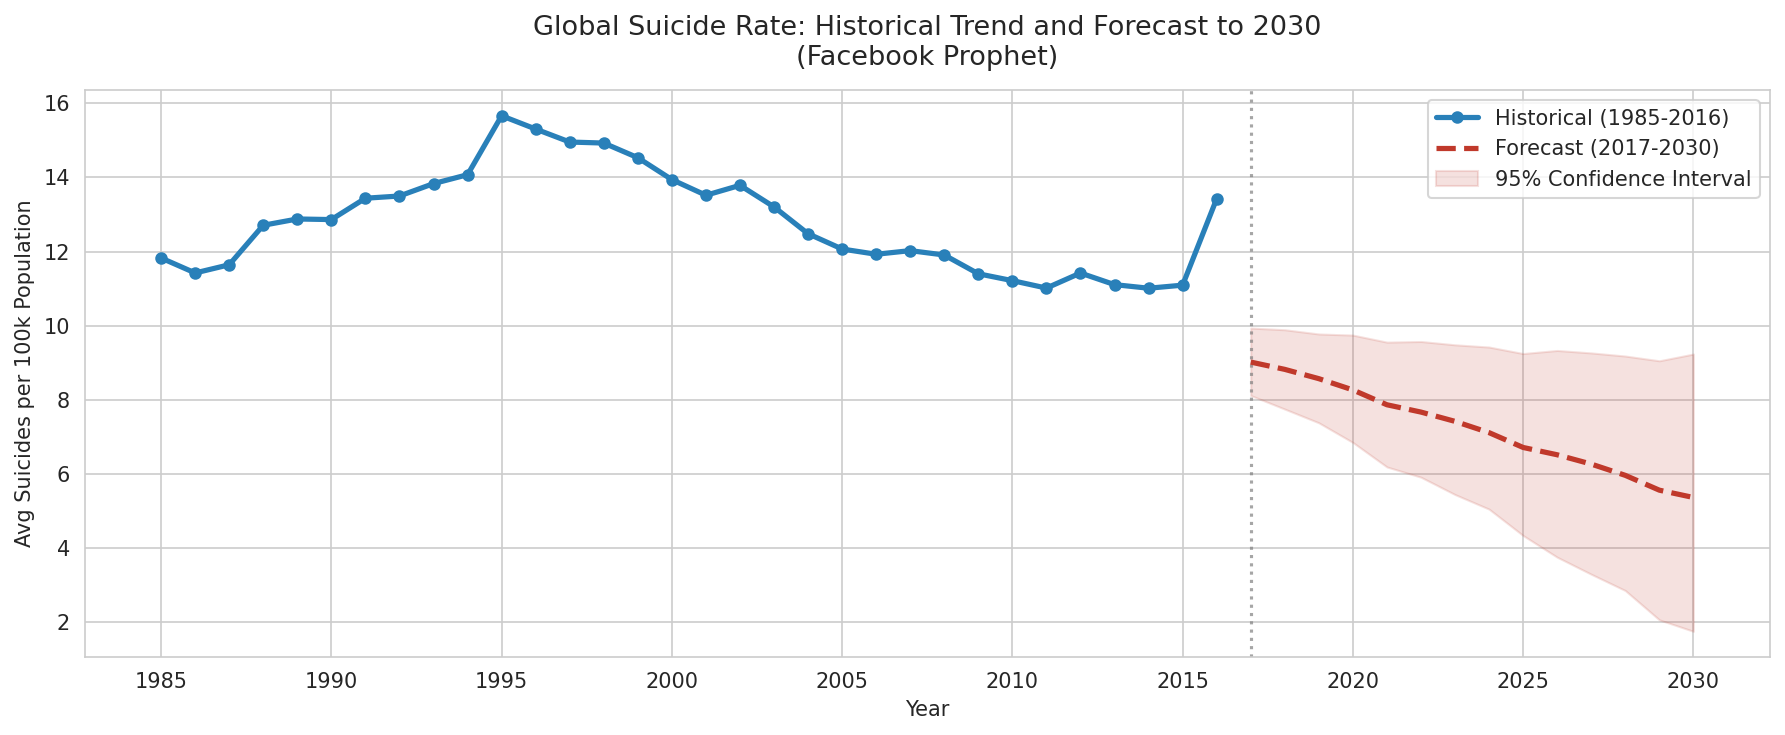

Saved: plot_11_prophet_forecast.png


In [37]:
# ─────────────────────────────────────────────────────────────
# CELL 37 — PLOT: Historical data + Forecast to 2030
# Hero chart for the white paper:
#   Blue line     = historical data (1985-2016)
#   Red dashed    = Prophet forecast (2017-2030)
#   Shaded area   = 95% confidence interval
# ─────────────────────────────────────────────────────────────

forecast_future = forecast[forecast['ds'].dt.year >= 2017]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(ts_df['ds'], ts_df['y'],
        color='#2980b9', linewidth=2.5, marker='o',
        markersize=5, label='Historical (1985-2016)', zorder=3)

ax.plot(forecast_future['ds'], forecast_future['yhat'],
        color='#c0392b', linewidth=2.5, linestyle='--',
        label='Forecast (2017-2030)', zorder=3)

ax.fill_between(forecast_future['ds'],
                forecast_future['yhat_lower'],
                forecast_future['yhat_upper'],
                alpha=0.15, color='#c0392b', label='95% Confidence Interval')

ax.axvline(pd.Timestamp('2017-01-01'), color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.set_title('Global Suicide Rate: Historical Trend and Forecast to 2030\n(Facebook Prophet)',
             fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Avg Suicides per 100k Population')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('plot_11_prophet_forecast.png', bbox_inches='tight')
plt.show()
print('Saved: plot_11_prophet_forecast.png')

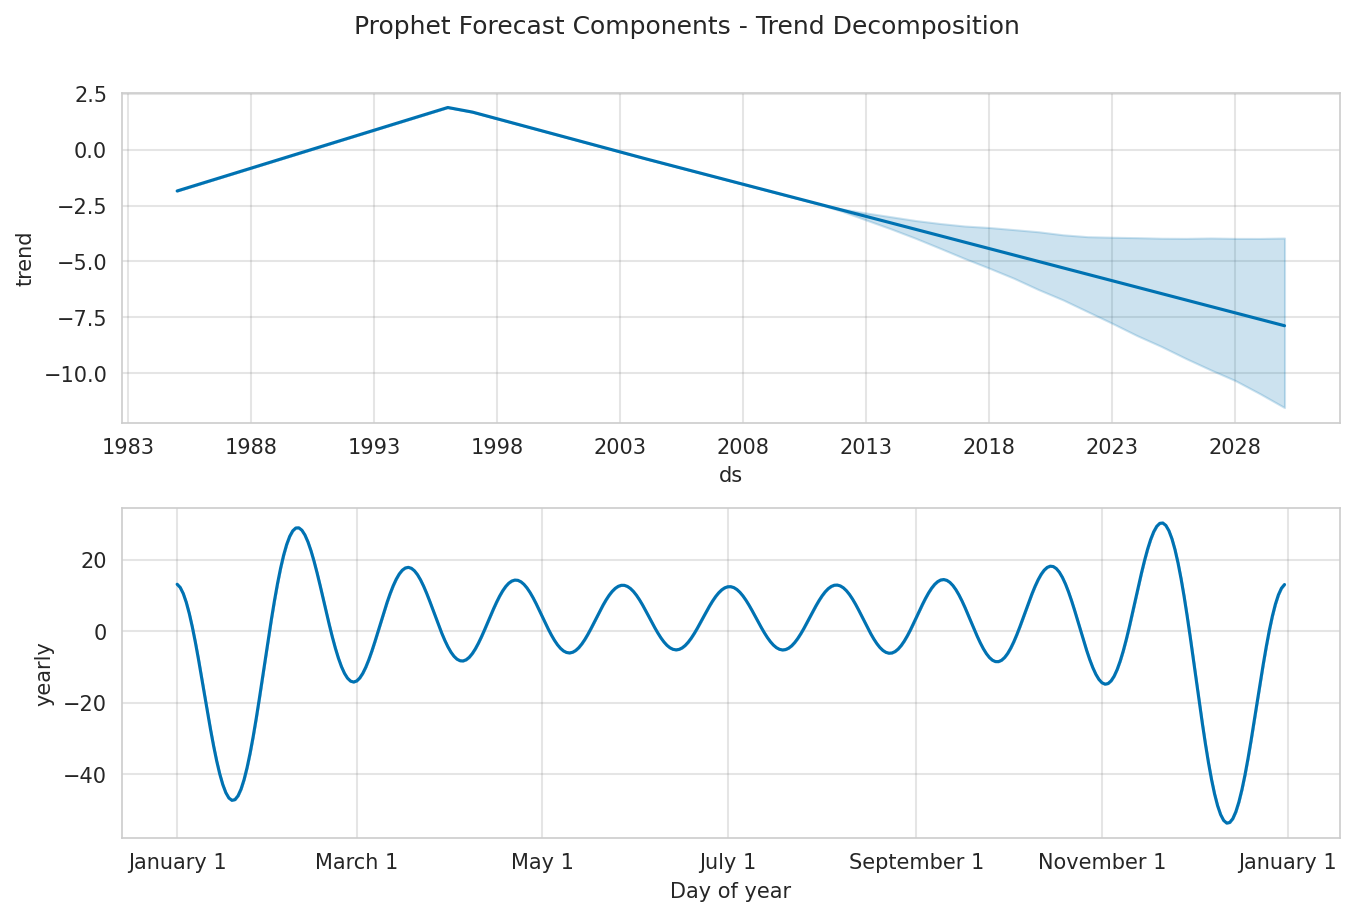

Saved: plot_12_prophet_components.png


In [38]:
# ─────────────────────────────────────────────────────────────
# CELL 38 — PLOT: Prophet trend decomposition
# Prophet decomposes the forecast into trend + seasonality.
# Shows the underlying trend direction clearly.
# ─────────────────────────────────────────────────────────────

fig = prophet_model.plot_components(forecast)
plt.suptitle('Prophet Forecast Components - Trend Decomposition', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('plot_12_prophet_components.png', bbox_inches='tight')
plt.show()
print('Saved: plot_12_prophet_components.png')

---
## SECTION 7 — Evaluation Summary

In [39]:
# ─────────────────────────────────────────────────────────────
# CELL 39 — Final consolidated evaluation report
# Prints a clean summary of all three models with metrics
# and plain-English business interpretation for the white paper.
# ─────────────────────────────────────────────────────────────

print('=' * 65)
print('  FINAL MODEL EVALUATION SUMMARY')
print('  Applied Predictive Analytics - SDG 3: Good Health')
print('=' * 65)

print('\nMODEL 1 - Random Forest Regression')
print(f'  Task         : Predict suicide rate per 100k population')
print(f'  RMSE         : {rmse_rf:.4f}')
print(f'  MAE          : {mae_rf:.4f}')
print(f'  R2 Score     : {r2_rf:.4f}')
print(f'  Interpretation: Model explains {r2_rf*100:.1f}% of variance in suicide rates.')

print('\nMODEL 2 - K-Means Clustering')
sil_final = silhouette_score(X_cluster_scaled, cluster_labels)
print(f'  Task           : Segment countries into risk profiles')
print(f'  Optimal k      : {OPTIMAL_K} clusters')
print(f'  Silhouette Score: {sil_final:.4f}  (0=overlap, 1=perfect separation)')
print(f'  Cluster labels : {list(label_map.values())}')

print('\nMODEL 3 - Facebook Prophet (Time Series)')
print(f'  Task           : Forecast global suicide rate 2017-2030')
print(f'  RMSE (test)    : {rmse_ts:.4f}')
print(f'  MAE  (test)    : {mae_ts:.4f}')
print(f'  MAPE (test)    : {mape_ts:.2f}%')

val_2030 = forecast[forecast['ds'].dt.year == 2030]['yhat'].values
if len(val_2030) > 0:
    print(f'  2030 Forecast  : {val_2030[0]:.2f} suicides/100k (with 95% CI)')

print('\n' + '=' * 65)
print('All plots saved as PNG - ready for white paper.')
print('=' * 65)

  FINAL MODEL EVALUATION SUMMARY
  Applied Predictive Analytics - SDG 3: Good Health

MODEL 1 - Random Forest Regression
  Task         : Predict suicide rate per 100k population
  RMSE         : 9.4006
  MAE          : 4.5694
  R2 Score     : 0.7471
  Interpretation: Model explains 74.7% of variance in suicide rates.

MODEL 2 - K-Means Clustering
  Task           : Segment countries into risk profiles
  Optimal k      : 2 clusters
  Silhouette Score: 0.3964  (0=overlap, 1=perfect separation)
  Cluster labels : ['Low Risk', 'Moderate Risk']

MODEL 3 - Facebook Prophet (Time Series)
  Task           : Forecast global suicide rate 2017-2030
  RMSE (test)    : 2.0279
  MAE  (test)    : 1.6390
  MAPE (test)    : 13.49%
  2030 Forecast  : 5.37 suicides/100k (with 95% CI)

All plots saved as PNG - ready for white paper.


In [40]:
# ─────────────────────────────────────────────────────────────
# CELL 40 — List all exported plot files
# ─────────────────────────────────────────────────────────────

import os
plots = sorted([f for f in os.listdir('.') if f.startswith('plot_') and f.endswith('.png')])
print('Exported chart files for white paper:')
for p in plots:
    print(f'  {p}')

Exported chart files for white paper:
  plot_01_global_trend.png
  plot_02_by_sex.png
  plot_03_by_age.png
  plot_04_top_countries.png
  plot_05_correlation.png
  plot_06_feature_importance.png
  plot_07_actual_vs_predicted.png
  plot_08_elbow_silhouette.png
  plot_09_clusters_pca.png
  plot_10_cluster_bar.png
  plot_11_prophet_forecast.png
  plot_12_prophet_components.png
